# LLM Evaluation: LLM as a Judge

In this example, we evaluate a shopping assistant that answers common customer questions in an e-commerce setting. The questions are intentionally simple and generic (returns, shipping, payments, order changes), making it easier to reason about what a “good” answer looks like.

We build a small dataset of queries paired with reference answers that represent acceptable high-level responses. The goal is not to match exact wording, but to check whether the assistant provides useful, accurate, and non-misleading information.

We then:
* generate answers with an LLM-based assistant
* compare them to reference answers
* use another LLM as a judge

The judge assigns a single label: correctness.

In practice, correctness is subjective and task-dependent.

You are encouraged to experiment with this criterion:
* make it stricter by reintroducing dimensions like addition and deletion (see commented parts in the judge prompt)
* relax what counts as “missing” information
* decide whether generic answers should pass or fail

Small changes in the definition can significantly affect evaluation results — and that’s the point.

In [28]:
# Import libraries
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from openai import OpenAI

In [ ]:
pd.set_option('display.max_colwidth', None)

## 1. Dataset

We store the evaluation set in two Python lists, then load it into a pandas DataFrame.


In [29]:
# Static dataset built from two lists

customer_queries = [
    "How can I track my order?",
    "My item arrived damaged. What should I do?",
    "I entered the wrong shipping address. What should I do?",
    "I need a different size. What is the usual process?",
    "Do you offer free returns on all items?",
    "How long does a refund usually take after a return?",
    "Do you have a student discount?",
    "How long is the warranty on your headphones?",
]

reference_answers = [
    "You can usually track an order from the shipping confirmation email or from your order history page. If the tracking link is not updating, contact support with your order number.",
    "Take photos of the item and the packaging, then contact support. Stores usually review the case and offer a replacement, refund, or return instructions.",
    "Contact support as soon as possible. Address changes are sometimes possible before shipment, but not always after the order has been processed.",
    "Check the store's return or exchange policy. If exchanges are offered, request one; otherwise, return the item and place a new order.",
    "This depends on the store's policy and the item category. Check the return policy or ask support before assuming returns are free.",
    "This varies by store and payment method. Refunds usually begin after the return is received and inspected.",
    "Discount availability depends on the store. Check the promotions page or contact support to confirm whether a student discount exists.",
    "Warranty length depends on the product and seller. Check the product page or the warranty terms for the exact coverage period.",
]

topic = [
    "tracking",
    "damaged_item",
    "shipping_address",
    "exchange",
    "returns",
    "refund",
    "discount",
    "warranty",
]


In [30]:
df = pd.DataFrame(
    {
        "topic": topic,
        "customer_query": customer_queries,
        "reference_answer": reference_answers,
    }
)

df

,topic,customer_query,reference_answer
0,tracking,How can I track my order?,You can usually track an order from the shippi...
1,damaged_item,My item arrived damaged. What should I do?,"Take photos of the item and the packaging, the..."
2,shipping_address,I entered the wrong shipping address. What sho...,Contact support as soon as possible. Address c...
3,exchange,I need a different size. What is the usual pro...,Check the store's return or exchange policy. I...
4,returns,Do you offer free returns on all items?,This depends on the store's policy and the ite...
5,refund,How long does a refund usually take after a re...,This varies by store and payment method. Refun...
6,discount,Do you have a student discount?,Discount availability depends on the store. Ch...
7,warranty,How long is the warranty on your headphones?,Warranty length depends on the product and sel...


## 2. Generate model answers

We call the OpenAI API to answer each customer question.

The prompt asks for short, generic shopping support answers and avoids confident store-specific claims.


In [31]:
SHOP_ASSISTANT_PROMPT = (
    "You are a shopping assistant. "
    "Answer in 1 to 3 sentences. "
    "Use common e-commerce guidance. "
    #"Do not confidently invent store-specific policies. "
    #"When a detail is store-specific or unknown, say that it depends on the store and suggest checking the policy page or contacting support."
)


def generate_shop_assistant_answer(client, customer_query, model="gpt-5.4-mini"):
    response = client.responses.create(
        model=model,
        input=[
            {"role": "system", "content": SHOP_ASSISTANT_PROMPT},
            {"role": "user", "content": customer_query},
        ],
    )
    return response.output_text.strip()


In [32]:
# Optional real API call
# If OPENAI_API_KEY is available, generate model answers live.
# Otherwise, use static demo outputs so the notebook remains runnable.

demo_model_answers = [
    "You can usually track your order from the shipping confirmation email or from your order history page. If the tracking does not update, contact support with your order number.",
    "Take photos of the item and the packaging, then contact support. They will usually review the case and help with a replacement, refund, or return.",
    "Contact support as soon as possible. Address updates are sometimes possible before shipment, but they may not be possible after the order has been processed.",
    "Check the store's return or exchange policy. If exchanges are available, request one; otherwise, return the item and place a new order.",
    "Yes, returns are usually free on most items unless the product is marked final sale.",
    "Refunds are usually processed within 5 to 10 business days after the warehouse receives your return.",
    "Yes, we offer a 10% student discount after verification.",
    "The headphones come with a 2-year warranty.",
]

api_key = os.getenv("OPENAI_API_KEY")

if api_key:
    client = OpenAI(api_key=api_key)
    df["model_answer"] = df["customer_query"].apply(
        lambda x: generate_shop_assistant_answer(client, x)
    )
else:
    df["model_answer"] = demo_model_answers

df[["customer_query", "reference_answer", "model_answer"]].head()


,customer_query,reference_answer,model_answer
0,How can I track my order?,You can usually track an order from the shippi...,You can usually track your order by checking t...
1,My item arrived damaged. What should I do?,"Take photos of the item and the packaging, the...","Sorry about that—if your item arrived damaged,..."
2,I entered the wrong shipping address. What sho...,Contact support as soon as possible. Address c...,"If your order hasn’t shipped yet, contact the ..."
3,I need a different size. What is the usual pro...,Check the store's return or exchange policy. I...,"Usually, you can request an exchange through t..."
4,Do you offer free returns on all items?,This depends on the store's policy and the ite...,"Return policies can vary by item, seller, and ..."


## 3. Judge correctness

The judge compares the customer query, the reference answer, and the model answer.

It returns one label for one criterion: **correctness**.


In [33]:
JUDGE_PROMPT = (
    "You are an evaluation judge for a shopping assistant. "
    "Compare the model answer with the reference answer for the same customer query. "
    "Evaluate one criterion only: correctness. "
    "The answer passes only if it matches the reference without unsupported additions, important deletions, or contradictions. "
   # "If the model adds store-specific details that are not supported by the reference, mark it as failed. "
   # "If the model omits important guidance from the reference, mark it as failed. "
    "If the model contradicts the reference, mark it as failed. "
    "Return valid JSON only with this schema: "
    "{"
    "\"correctness\": {\"label\": \"pass|failed\", \"reasoning\": \"...\"}"
    "}"
)


def judge_correctness(client, customer_query, reference_answer, model_answer, model="gpt-5.4-mini"):
    response = client.responses.create(
        model=model,
        input=[
            {"role": "system", "content": JUDGE_PROMPT},
            {
                "role": "user",
                "content": (
                    f"Customer query: {customer_query}\n\n"
                    f"Reference answer: {reference_answer}\n\n"
                    f"Model answer: {model_answer}"
                ),
            },
        ],
    )
    return json.loads(response.output_text)


In [34]:
# Optional real judge call
# Without an API key, use static demo judgements.

demo_judgements = [
    {
        "correctness": {
            "label": "pass",
            "reasoning": "The answer stays aligned with the reference and keeps the same guidance."
        }
    },
    {
        "correctness": {
            "label": "pass",
            "reasoning": "The answer matches the reference and does not introduce unsupported policy details."
        }
    },
    {
        "correctness": {
            "label": "pass",
            "reasoning": "The answer preserves the key point that changes may be possible before shipment but not always later."
        }
    },
    {
        "correctness": {
            "label": "pass",
            "reasoning": "The answer matches the reference exchange guidance."
        }
    },
    {
        "correctness": {
            "label": "failed",
            "reasoning": "The answer claims that returns are usually free, but the reference says this depends on the store and item category."
        }
    },
    {
        "correctness": {
            "label": "failed",
            "reasoning": "The answer adds a specific refund timeline that is not supported by the reference."
        }
    },
    {
        "correctness": {
            "label": "failed",
            "reasoning": "The answer invents a specific student discount instead of stating that availability depends on the store."
        }
    },
    {
        "correctness": {
            "label": "failed",
            "reasoning": "The answer gives a specific warranty period that is not supported by the reference."
        }
    },
]

if api_key:
    client = OpenAI(api_key=api_key)
    df["judge_result"] = df.apply(
        lambda row: judge_correctness(
            client,
            row["customer_query"],
            row["reference_answer"],
            row["model_answer"],
        ),
        axis=1,
    )
else:
    df["judge_result"] = demo_judgements

df[["customer_query", "model_answer", "judge_result"]].head()


,customer_query,model_answer,judge_result
0,How can I track my order?,You can usually track your order by checking t...,"{'correctness': {'label': 'pass', 'reasoning':..."
1,My item arrived damaged. What should I do?,"Sorry about that—if your item arrived damaged,...","{'correctness': {'label': 'failed', 'reasoning..."
2,I entered the wrong shipping address. What sho...,"If your order hasn’t shipped yet, contact the ...","{'correctness': {'label': 'failed', 'reasoning..."
3,I need a different size. What is the usual pro...,"Usually, you can request an exchange through t...","{'correctness': {'label': 'failed', 'reasoning..."
4,Do you offer free returns on all items?,"Return policies can vary by item, seller, and ...","{'correctness': {'label': 'pass', 'reasoning':..."


In [35]:
# Normalize judge output into tabular columns

judge_df = pd.json_normalize(df["judge_result"])

judge_df = judge_df.rename(
    columns={
        "correctness.label": "correctness_label",
        "correctness.reasoning": "correctness_reasoning",
    }
)

df = pd.concat([df.drop(columns=["judge_result"]), judge_df], axis=1)

df["overall_label"] = df["correctness_label"]

df[
    [
        "topic",
        "customer_query",
        "model_answer",
        "correctness_label",
        "correctness_reasoning",
    ]
].head()


,topic,customer_query,model_answer,correctness_label,correctness_reasoning
0,tracking,How can I track my order?,You can usually track your order by checking t...,pass,The model answer matches the reference guidanc...
1,damaged_item,My item arrived damaged. What should I do?,"Sorry about that—if your item arrived damaged,...",failed,The model answer adds unsupported details beyo...
2,shipping_address,I entered the wrong shipping address. What sho...,"If your order hasn’t shipped yet, contact the ...",failed,The model answer adds unsupported details abou...
3,exchange,I need a different size. What is the usual pro...,"Usually, you can request an exchange through t...",failed,The reference answer says to check the store’s...
4,returns,Do you offer free returns on all items?,"Return policies can vary by item, seller, and ...",pass,The model answer matches the reference in subs...


## 4. Summarise results

After judging each row, we aggregate the labels with pandas.


In [36]:
summary = df.groupby("topic").agg(
    total_examples=("topic", "count"),
    passed=("correctness_label", lambda x: (x == "pass").sum()),
    failed=("correctness_label", lambda x: (x == "failed").sum()),
    failed_rate=("correctness_label", lambda x: (x == "failed").mean()),
)

summary["failed_rate"] = (summary["failed_rate"] * 100).round(1)

summary


,total_examples,passed,failed,failed_rate
topic,,,,
damaged_item,1,0,1,100.0
discount,1,0,1,100.0
exchange,1,0,1,100.0
refund,1,0,1,100.0
returns,1,1,0,0.0
shipping_address,1,0,1,100.0
tracking,1,1,0,0.0
warranty,1,0,1,100.0


In [37]:
correctness_report = pd.DataFrame({
    "label": ["pass", "failed"],
    "count": [
        int((df["correctness_label"] == "pass").sum()),
        int((df["correctness_label"] == "failed").sum()),
    ],
})

correctness_report["share_%"] = (
    correctness_report["count"] / len(df) * 100
).round(1)

correctness_report


,label,count,share_%
0,pass,2,25.0
1,failed,6,75.0


In [38]:
failed_cases = df.loc[
    df["correctness_label"] == "failed",
    [
        "topic",
        "customer_query",
        "reference_answer",
        "model_answer",
        "correctness_label",
        "correctness_reasoning",
    ],
]

failed_cases


,topic,customer_query,reference_answer,model_answer,correctness_label,correctness_reasoning
1,damaged_item,My item arrived damaged. What should I do?,"Take photos of the item and the packaging, the...","Sorry about that—if your item arrived damaged,...",failed,The model answer adds unsupported details beyo...
2,shipping_address,I entered the wrong shipping address. What sho...,Contact support as soon as possible. Address c...,"If your order hasn’t shipped yet, contact the ...",failed,The model answer adds unsupported details abou...
3,exchange,I need a different size. What is the usual pro...,Check the store's return or exchange policy. I...,"Usually, you can request an exchange through t...",failed,The reference answer says to check the store’s...
5,refund,How long does a refund usually take after a re...,This varies by store and payment method. Refun...,Refunds usually take about 5–10 business days ...,failed,The model adds unsupported specifics about a 5...
6,discount,Do you have a student discount?,Discount availability depends on the store. Ch...,I’m not able to see store-specific discount pr...,failed,The model answer adds unsupported specifics ab...
7,warranty,How long is the warranty on your headphones?,Warranty length depends on the product and sel...,Warranty length varies by headphone model and ...,failed,The model answer adds an unsupported general c...


## 5. Visualise results

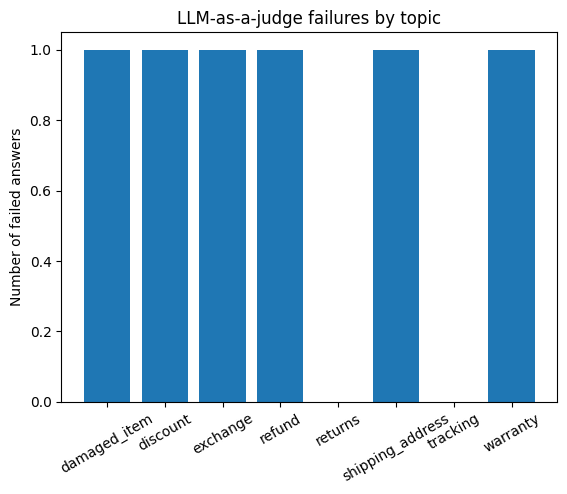

In [39]:
plt.figure()

plt.bar(summary.index, summary["failed"])
plt.ylabel("Number of failed answers")
plt.title("LLM-as-a-judge failures by topic")
plt.xticks(rotation=30)

plt.show()

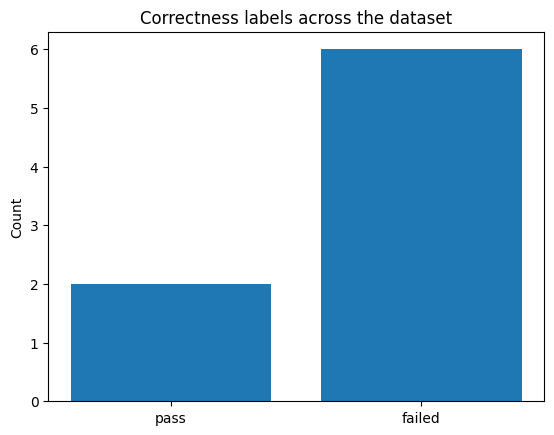

In [40]:
plt.figure()

plt.bar(correctness_report["label"], correctness_report["count"])
plt.ylabel("Count")
plt.title("Correctness labels across the dataset")

plt.show()
